
Introduction
This analysis looks at what influences national happiness across many countries from 2005 to 2022. By combining data from the World Happiness Report and World Bank Development Indicators, the goal is to find out which social and economic factors relate most to how happy people feel.

Some of the main things we’re checking include:

⦁ The happiness score people report for their own lives (called the ladder score)  
⦁ How wealthy a country is per person (GDP per capita)  
⦁ How much the country spends on its military    
⦁ How much money the government spends on education and health  
⦁ The percentage of the population with access to electricity  
⦁ Whether a country is classified as developed or developing  

The idea is to see how these factors connect to happiness and give useful ideas for policies that could improve well-being worldwide.


1. Setup: Loading Data and Libraries:
Imported key tools for data analysis and visualization. Loaded two main datasets: one with development indicators and one with happiness scores. Created backup copies of the original files to keep them safe during cleaning and transformation.

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="muted")


# Use relative file paths 
dev_path = "./data/world_dev_indicators.csv"
happiness_path = "./data/World_Happiness_Report.csv"

# Load datasets
dev_df = pd.read_csv(dev_path)
happiness_df = pd.read_csv(happiness_path)

# Backing up original datasets
dev_df_original = dev_df.copy()
happiness_df_original = happiness_df.copy()  

print("World Development Indicators Sample:")
display(dev_df.head())

print("\nWorld Happiness Report Sample:")
display(happiness_df.head())

World Development Indicators Sample:


,country,date,agricultural_land%,forest_land%,land_area,avg_precipitation,trade_in_services%,control_of_corruption_estimate,control_of_corruption_std,access_to_electricity%,...,multidimensional_poverty_headcount_ratio%,gini_index,birth_rate,death_rate,life_expectancy_at_birth,population,rural_population,voice_and_accountability_estimate,voice_and_accountability_std,intentional_homicides
0,Afghanistan,1960-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,50.340,31.921,32.535,8622466.0,7898093.0,NaN,NaN,NaN
1,Afghanistan,1961-01-01,57.878356,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,...,NaN,NaN,50.443,31.349,33.068,8790140.0,8026804.0,NaN,NaN,NaN
2,Afghanistan,1962-01-01,57.955016,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,...,NaN,NaN,50.570,30.845,33.547,8969047.0,8163985.0,NaN,NaN,NaN
3,Afghanistan,1963-01-01,58.031676,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,...,NaN,NaN,50.703,30.359,34.016,9157465.0,8308019.0,NaN,NaN,NaN
4,Afghanistan,1964-01-01,58.116002,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,...,NaN,NaN,50.831,29.867,34.494,9355514.0,8458694.0,NaN,NaN,NaN



World Happiness Report Sample:


,Country Name,Regional Indicator,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption,Positive Affect,Negative Affect,Confidence In National Government
0,Afghanistan,South Asia,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686,0.414297,0.258195,0.612072
1,Afghanistan,South Asia,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035,0.481421,0.237092,0.611545
2,Afghanistan,South Asia,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766,0.516907,0.275324,0.299357
3,Afghanistan,South Asia,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109,0.479835,0.267175,0.307386
4,Afghanistan,South Asia,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620,0.613513,0.267919,0.435440


 2. DATA CLEANING:
Cleaning: Development Indicators Data
Extracted the year from the original datetime column and saved it as an integer-based Year column. Dropped the original date column after extraction. Renamed some columns. Checked data types across all columns and calculated the percentage and numbers of non-missing and missing values.

In [100]:
# Converted 'date' column from string to datetime format
dev_df['date'] = pd.to_datetime(dev_df['date'], errors='coerce')

In [101]:
# Used the pandas datetime accessor '.dt' to extract the year part from the 'date' column, this created a new column, and then i changed its type
dev_df['Year'] = dev_df['date'].dt.year.astype('Int32')

# Drop the 'date' column
dev_df.drop(columns=['date'], inplace=True)

In [102]:
# Checking the name of the columns
for col in dev_df.columns:
    print(col)

country
agricultural_land%
forest_land%
land_area
avg_precipitation
trade_in_services%
control_of_corruption_estimate
control_of_corruption_std
access_to_electricity%
renewvable_energy_consumption%
electric_power_consumption
CO2_emisions
other_greenhouse_emisions
population_density
inflation_annual%
real_interest_rate
risk_premium_on_lending
research_and_development_expenditure%
central_goverment_debt%
tax_revenue%
expense%
goverment_effectiveness_estimate
goverment_effectiveness_std
human_capital_index
doing_business
time_to_get_operation_license
statistical_performance_indicators
individuals_using_internet%
logistic_performance_index
military_expenditure%
GDP_current_US
political_stability_estimate
political_stability_std
rule_of_law_estimate
rule_of_law_std
regulatory_quality_estimate
regulatory_quality_std
government_expenditure_on_education%
government_health_expenditure%
multidimensional_poverty_headcount_ratio%
gini_index
birth_rate
death_rate
life_expectancy_at_birth
population

In [103]:
# Showing  unique years including missing values 
unique_years_with_dev = dev_df['Year'].unique()
print(unique_years_with_dev)


<IntegerArray>
[1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972,
 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985,
 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998,
 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Length: 64, dtype: Int32


In [104]:
# Go through each column in the DataFrame one by one
for col in dev_df.columns:
    # summing non missing values
    non_missing = dev_df[col].notna().sum()
    
    # Counted numbers of rows in the column
    total = len(dev_df[col])
    
    # Calculated the percentage of non-missing data in this column
    percent_present = (non_missing / total) * 100
    print(f"{col}: {percent_present:.2f}%")


country: 100.00%
agricultural_land%: 85.19%
forest_land%: 47.34%
land_area: 86.44%
avg_precipitation: 58.40%
trade_in_services%: 53.24%
control_of_corruption_estimate: 27.69%
control_of_corruption_std: 27.69%
access_to_electricity%: 42.54%
renewvable_energy_consumption%: 46.76%
electric_power_consumption: 45.10%
CO2_emisions: 42.89%
other_greenhouse_emisions: 42.89%
population_density: 86.27%
inflation_annual%: 62.46%
real_interest_rate: 25.57%
risk_premium_on_lending: 13.72%
research_and_development_expenditure%: 16.73%
central_goverment_debt%: 12.04%
tax_revenue%: 29.67%
expense%: 27.61%
goverment_effectiveness_estimate: 27.55%
goverment_effectiveness_std: 27.55%
human_capital_index: 3.48%
doing_business: 1.09%
time_to_get_operation_license: 2.15%
statistical_performance_indicators: 7.16%
individuals_using_internet%: 46.57%
logistic_performance_index: 8.15%
military_expenditure%: 58.60%
GDP_current_US: 76.41%
political_stability_estimate: 27.91%
political_stability_std: 27.91%
rule_o

In [105]:
# Filtered dataset to include only rows where 'Year' is between 2005 and 2022
dev_df_filtered = dev_df[(dev_df['Year'] >= 2005) & (dev_df['Year'] <= 2022)] 


In [106]:
# Make a full copy of the filtered DataFrame 
dev_df_filtered = dev_df_filtered.copy()


In [107]:
# RENAMING COLUMNS
dev_df_filtered.rename(columns={
    'military_expenditure%': 'military_expenditure',
    'access_to_electricity%': 'access_to_electricity',
    'research_and_development_expenditure%': 'research_and_development_expenditure',
    'government_expenditure_on_education%': 'government_expenditure_on_education',
    'government_health_expenditure%': 'government_health_expenditure',
    'renewvable_energy_consumption%': 'renewvable_energy_consumption',
    'research_and_development_expenditure%': 'research_and_development_expenditure',
}, inplace=True)

In [108]:
# DEFINE THE COLUMNS TO KEEP 
columns_to_keep = [
    'country', 'Year', 'military_expenditure',
    'access_to_electricity', 'population_density',
    'government_expenditure_on_education',
    'government_health_expenditure',
    'renewvable_energy_consumption',
]
# CREATE TRIMMED DATAFRAME
dev_df_trimmed = dev_df_filtered[columns_to_keep].copy()
print(dev_df_trimmed.head())



        country  Year  military_expenditure  access_to_electricity  \
45  Afghanistan  2005              1.992066              28.669672   
46  Afghanistan  2006              1.896234              33.544418   
47  Afghanistan  2007              2.566267              38.440002   
48  Afghanistan  2008              2.335546              42.400000   
49  Afghanistan  2009              2.087413              48.279007   

    population_density  government_expenditure_on_education  \
45           37.427274                                  NaN   
46           39.009159                             4.684761   
47           39.714979                             4.174895   
48           40.518221                             4.383672   
49           41.987193                             4.810640   

    government_health_expenditure  renewvable_energy_consumption  
45                       0.529184                          33.88  
46                       0.497840                          31.89  

In [109]:
# Checked missing values, missing percentage, and data types for each column in dev_df_trimmed
def sum_missing_values_and_dtypes(dtf: pd.DataFrame) -> pd.DataFrame:
    """Gives a summary DataFrame with missing value counts, missing percentages,
    and data types for each column in the given DataFrame."""
    missing = dtf.isna().sum()
    percent = (missing / len(dtf) * 100)
    dtypes = dtf.dtypes
# Joined three Series into a dictionary and convert it into a DataFrame
    summary = pd.DataFrame({'missing_values': missing, 'missing_percent': percent, 'data_type': dtypes})
    return summary
# Called the function and passed the dev_df_trimmed DataFrame as input 
summary = sum_missing_values_and_dtypes(dev_df_trimmed)
print(summary)

                                     missing_values  missing_percent data_type
country                                           0         0.000000    object
Year                                              0         0.000000     Int32
military_expenditure                           1409        28.661513   float64
access_to_electricity                           453         9.214809   float64
population_density                              455         9.255492   float64
government_expenditure_on_education            1562        31.773800   float64
government_health_expenditure                  1145        23.291294   float64
renewvable_energy_consumption                   692        14.076485   float64


Cleaning: Happiness Dataset

Checked the column names and renamed some for clarity, including changing Country to country to match the development dataset. Calculated the percentage and number of missing values to assess data quality. Verified data types for all columns and converted the Year column to the same data type as in the development data for easier merging. Renamed columns. Dropped some columns.

In [110]:

# Created a function to show the names of all columns in my  table (DataFrame)
def print_column_names(fun: pd.DataFrame) -> None:
    """Print all column names in a DataFrame."""
    for col in fun.columns:
        print(col)
print_column_names(happiness_df)


Country Name
Regional Indicator
Year
Life Ladder
Log GDP Per Capita
Social Support
Healthy Life Expectancy At Birth
Freedom To Make Life Choices
Generosity
Perceptions Of Corruption
Positive Affect
Negative Affect
Confidence In National Government


In [111]:
# Renamed the column 'Country Name' to 'country' 
happiness_df.rename(columns={'Country Name': 'country'}, inplace=True)

In [112]:
# Check missing values, missing percentage, and data types for each column in dev_df_trimmed
summary = sum_missing_values_and_dtypes(happiness_df)
print(summary)

                                   missing_values  missing_percent data_type
country                                         0         0.000000    object
Regional Indicator                            112         5.093224    object
Year                                            0         0.000000     int64
Life Ladder                                     0         0.000000   float64
Log GDP Per Capita                             20         0.909504   float64
Social Support                                 13         0.591178   float64
Healthy Life Expectancy At Birth               54         2.455662   float64
Freedom To Make Life Choices                   33         1.500682   float64
Generosity                                     73         3.319691   float64
Perceptions Of Corruption                     116         5.275125   float64
Positive Affect                                24         1.091405   float64
Negative Affect                                16         0.727603   float64

In [113]:
# Printed the data type of each column 
print(happiness_df.dtypes)


country                               object
Regional Indicator                    object
Year                                   int64
Life Ladder                          float64
Log GDP Per Capita                   float64
Social Support                       float64
Healthy Life Expectancy At Birth     float64
Freedom To Make Life Choices         float64
Generosity                           float64
Perceptions Of Corruption            float64
Positive Affect                      float64
Negative Affect                      float64
Confidence In National Government    float64
dtype: object


In [114]:

# converted  Year column to Int32 type
happiness_df['Year'] = happiness_df['Year'].astype('Int32')
print(happiness_df.dtypes['Year'])

Int32


In [115]:
# Checking columns
print_column_names(happiness_df)

country
Regional Indicator
Year
Life Ladder
Log GDP Per Capita
Social Support
Healthy Life Expectancy At Birth
Freedom To Make Life Choices
Generosity
Perceptions Of Corruption
Positive Affect
Negative Affect
Confidence In National Government


Visualization: Missing Data Heatmap (happiness_df)
Created a heatmap to visualize the pattern of missing values in the happiness dataset. 

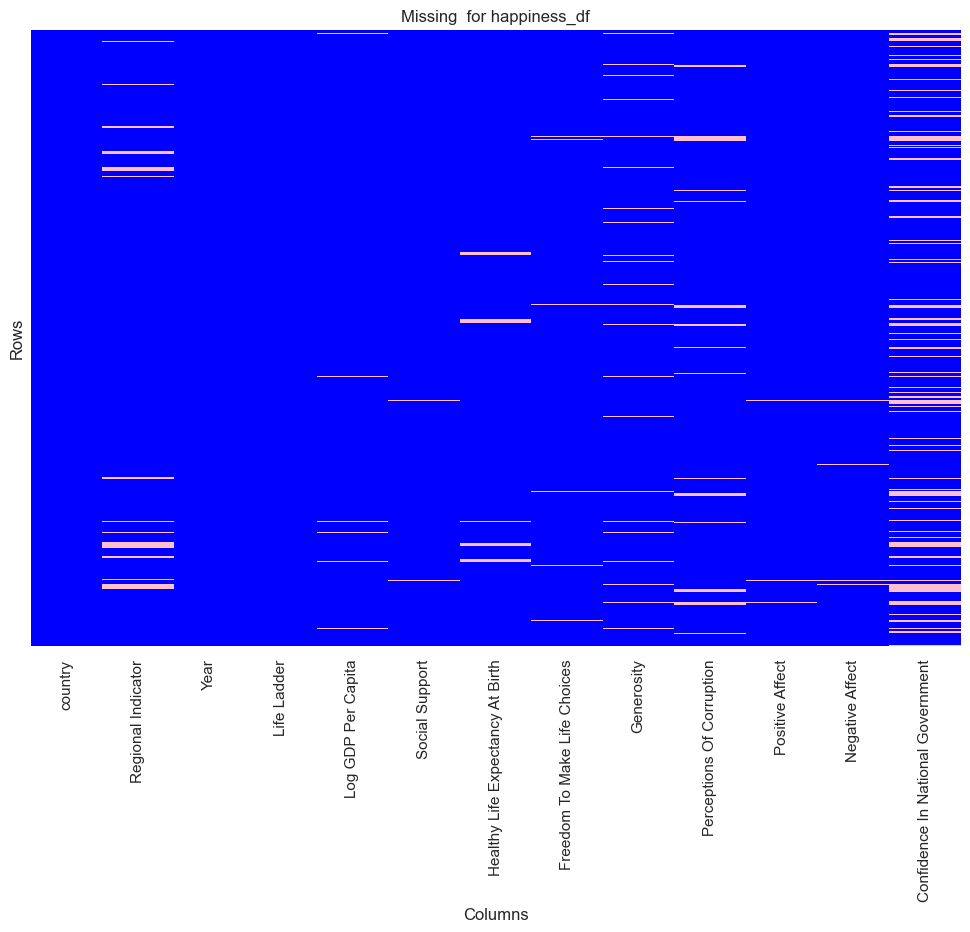

In [116]:

from matplotlib.colors import ListedColormap

# Set up the plot size
plt.figure(figsize=(12, 8))

# Chose colors: pink = missing, blue = present
custom_colors = ListedColormap(['blue', 'pink'])



# Create the heatmap: pink = missing, blue = present
sns.heatmap(happiness_df.isna(), 
 cmap=custom_colors,
 cbar=False,  
 yticklabels=False)

            
plt.title("Missing  for happiness_df")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()



Findings:
The dataset contains missing values in several key columns. The most affected variables are: confidnce in national government, positive effect, and negative effect.


In [154]:
# RENAMING COLUMNS
happiness_df.rename(columns={
    'Life Ladder': 'Happiness_Score',
    'Log GDP Per Capita': 'Log_GDP_per_Capita'
}, inplace=True)


In [155]:
# Selected specific columns from the happiness_df for analysis
happiness_df_trimmed = happiness_df[['country', 'Year', 'Happiness_Score', 'Generosity', 'Log_GDP_per_Capita']]

In [156]:
# Print the head of the dataframe
print("Trimmed Happiness Data Sample:")
print(happiness_df_trimmed.head())


Trimmed Happiness Data Sample:
       country  Year  Happiness_Score  Generosity  Log_GDP_per_Capita
0  Afghanistan  2008         3.723590    0.167652            7.350416
1  Afghanistan  2009         4.401778    0.190809            7.508646
2  Afghanistan  2010         4.758381    0.121316            7.613900
3  Afghanistan  2011         3.831719    0.163571            7.581259
4  Afghanistan  2012         3.782938    0.237588            7.660506


I created a dictionary to map inconsistent country names across datasets (e.g., renaming to match World Bank naming conventions). Applied the country_rename_map to replace country names in the happiness dataset using .replace().


In [157]:
# Checking the number of unique countries in each DataFrame
print("Unique countries in World Bank data:", dev_df_trimmed['country'].nunique())
print("Unique countries in Happiness data:", happiness_df_trimmed['country'].nunique())



Unique countries in World Bank data: 274
Unique countries in Happiness data: 165


In [158]:
# Got unique countries from both datasets and converted them to sets
countries_dev = set(dev_df_trimmed['country'].unique())
countries_happy = set(happiness_df_trimmed['country'].unique())


In [159]:
# Showing  differences
only_in_dev = countries_dev - countries_happy
only_in_happy = countries_happy - countries_dev

In [160]:
# Print countries only in only_in_dev dataset and only_in_happy datasets
print("Countries only in World Bank data:", only_in_dev)
print("Countries only in Happiness data:", only_in_happy)


Countries only in World Bank data: {'French Polynesia', 'Africa Eastern and Southern', 'Europe & Central Asia (excluding high income)', 'San Marino', 'Late-demographic dividend', 'Latin America & Caribbean (IDA & IBRD)', 'Seychelles', 'Congo, Dem. Rep.', 'Pacific island small states', 'British Virgin Islands', 'Least developed countries: UN classification', 'St. Martin (French part)', 'Latin America & Caribbean (excluding high income)', 'Syrian Arab Republic', 'Guam', 'Middle East & North Africa (IDA & IBRD)', 'Cabo Verde', 'Korea, Rep.', 'Czech Republic', 'East Asia & Pacific (excluding high income)', 'Middle income', 'Egypt, Arab Rep.', 'Grenada', 'Liechtenstein', 'Central Europe and the Baltics', 'Europe & Central Asia (IDA & IBRD)', 'Arab World', 'IDA & IBRD total', 'Low income', 'Faroe Islands', 'Marshall Islands', 'Turkey', 'Other small states', 'Slovak Republic', 'Pre-demographic dividend', 'Yemen, Rep.', 'Samoa', 'Timor-Leste', 'Nauru', 'Latin America & Caribbean', 'Sao Tome an

In [161]:
country_rename_map = {
    'Russia': 'Russian Federation',
    'Gambia': 'Gambia, The',
    'Vietnam': 'Viet Nam',
    'Iran': 'Iran, Islamic Rep.',
    'Egypt': 'Egypt, Arab Rep.',
    'South Korea': 'Korea, Rep.',
    'Ivory Coast': "Cote d'Ivoire",
    'Congo (Kinshasa)': 'Congo, Dem. Rep.',
    'Congo (Brazzaville)': 'Congo, Rep.',
    'Slovakia': 'Slovak Republic',
    'Venezuela': 'Venezuela, RB',
    'Hong Kong S.A.R. of China': 'Hong Kong SAR, China',
    'Yemen': 'Yemen, Rep.',
    'State of Palestine': 'West Bank and Gaza',
    'Laos': 'Lao PDR',
    'Kyrgyzstan': 'Kyrgyz Republic',
    
    # Entries to drop (no match in World Bank data)
    'Kosovo': None,
    'Taiwan Province of China': None,
    'Somaliland region': None
}


In [162]:
# Copy the dataframe
happiness_df_trimmed = happiness_df_trimmed.copy()

In [163]:
# Replace country names with chosen country_rename_map
happiness_df_trimmed['country'] = happiness_df_trimmed['country'].replace(country_rename_map)



In [164]:
# Filter to Selected Countries (i am aiming toward total of 34)
selected_countries = [
    # Africa
    'South Africa', 'Kenya', 'Egypt, Arab Rep.', 'Ghana', 'Ethiopia', 'Botswana',
    # Asia
    'China', 'India', 'Japan', 'Korea, Rep.', 'Indonesia', 'Viet Nam', 'Bangladesh', 'Pakistan',
    # North America
    'United States', 'Canada', 'Mexico', 'Cuba',
    # South America
    'Chile', 'Uruguay', 'Colombia', 'Argentina', 'Brazil', 'Peru',
    # Europe
    'Germany', 'France', 'United Kingdom', 'Italy', 'Spain', 'Russian Federation', 'Poland', 'Netherlands', 'Ukraine',
    # Middle East
    'Iran, Islamic Rep.', 'Saudi Arabia', 'Israel'
]


In [165]:
# Copy dataframes
dev_df_filtered_1 = dev_df_trimmed[dev_df_trimmed['country'].isin(selected_countries)].copy()
happiness_df_filtered_1 = happiness_df_trimmed[happiness_df_trimmed['country'].isin(selected_countries)].copy()


In [166]:
print("Filtered World Bank countries (dev_df_filtered_1):", dev_df_filtered_1['country'].unique())
print("Filtered Happiness countries (happiness_df_filtered_1):", happiness_df_filtered_1['country'].unique())


Filtered World Bank countries (dev_df_filtered_1): ['Argentina' 'Bangladesh' 'Botswana' 'Brazil' 'Canada' 'Chile' 'China'
 'Colombia' 'Cuba' 'Egypt, Arab Rep.' 'Ethiopia' 'France' 'Germany'
 'Ghana' 'India' 'Indonesia' 'Iran, Islamic Rep.' 'Israel' 'Italy' 'Japan'
 'Kenya' 'Korea, Rep.' 'Mexico' 'Netherlands' 'Pakistan' 'Peru' 'Poland'
 'Russian Federation' 'Saudi Arabia' 'South Africa' 'Spain' 'Ukraine'
 'United Kingdom' 'United States' 'Uruguay' 'Viet Nam']
Filtered Happiness countries (happiness_df_filtered_1): ['Argentina' 'Bangladesh' 'Botswana' 'Brazil' 'Canada' 'Chile' 'China'
 'Colombia' 'Cuba' 'Egypt, Arab Rep.' 'Ethiopia' 'France' 'Germany'
 'Ghana' 'India' 'Indonesia' 'Iran, Islamic Rep.' 'Israel' 'Italy' 'Japan'
 'Kenya' 'Mexico' 'Netherlands' 'Pakistan' 'Peru' 'Poland'
 'Russian Federation' 'Saudi Arabia' 'South Africa' 'Korea, Rep.' 'Spain'
 'Ukraine' 'United Kingdom' 'United States' 'Uruguay' 'Viet Nam']


In [167]:
# Got unique country names from the datasets and convert them into a set (for comparison)
countries_happy = set(happiness_df_filtered_1['country'].unique())
countries_dev = set(dev_df_filtered_1['country'].unique())

# Found countries that appear in the development dataset but not in the happiness dataset
only_in_dev = countries_dev - countries_happy
print("Countries only in dev dataset:", sorted(only_in_dev))

# Countries in happiness but not in dev
only_in_happy = countries_happy - countries_dev
print("Countries only in happiness dataset:", sorted(only_in_happy))


Countries only in dev dataset: []
Countries only in happiness dataset: []


In [168]:
print("World Bank filtered countries:")
print(sorted(dev_df_filtered_1['country'].unique()))

print("Happiness filtered countries:")
print(sorted(happiness_df_filtered_1['country'].unique()))


World Bank filtered countries:
['Argentina', 'Bangladesh', 'Botswana', 'Brazil', 'Canada', 'Chile', 'China', 'Colombia', 'Cuba', 'Egypt, Arab Rep.', 'Ethiopia', 'France', 'Germany', 'Ghana', 'India', 'Indonesia', 'Iran, Islamic Rep.', 'Israel', 'Italy', 'Japan', 'Kenya', 'Korea, Rep.', 'Mexico', 'Netherlands', 'Pakistan', 'Peru', 'Poland', 'Russian Federation', 'Saudi Arabia', 'South Africa', 'Spain', 'Ukraine', 'United Kingdom', 'United States', 'Uruguay', 'Viet Nam']
Happiness filtered countries:
['Argentina', 'Bangladesh', 'Botswana', 'Brazil', 'Canada', 'Chile', 'China', 'Colombia', 'Cuba', 'Egypt, Arab Rep.', 'Ethiopia', 'France', 'Germany', 'Ghana', 'India', 'Indonesia', 'Iran, Islamic Rep.', 'Israel', 'Italy', 'Japan', 'Kenya', 'Korea, Rep.', 'Mexico', 'Netherlands', 'Pakistan', 'Peru', 'Poland', 'Russian Federation', 'Saudi Arabia', 'South Africa', 'Spain', 'Ukraine', 'United Kingdom', 'United States', 'Uruguay', 'Viet Nam']


In [169]:

# Print the number of rows in the filtered development dataset
print(len(dev_df_filtered_1))

648


In [170]:
print(len(selected_countries))

36


In [171]:
# Checked the number of countries
num_countries_d = dev_df_filtered_1['country'].nunique()
print(num_countries_d)


36


In [172]:
# Checked the number of countries
num_countries_h: int = happiness_df_filtered_1['country'].nunique()
print(num_countries_h)

36


DATA CLEANING:
I visualized and assessed missing data, dropped incomplete columns. Filled the missing data. Experimented with multiple DataFrames.


In [173]:

# Check data for USA in happiness  dataset
happiness_df_filtered_1[happiness_df_filtered_1['country'] == 'United States']


,country,Year,Happiness_Score,Generosity,Log_GDP_per_Capita
2071,United States,2006,7.181794,NaN,10.920785
2072,United States,2007,7.512688,0.192796,10.931180
2073,United States,2008,7.280386,0.250227,10.922942
2074,United States,2009,7.158032,0.196253,10.887834
2075,United States,2010,7.163616,0.239416,10.906265
2076,United States,2011,7.115139,0.156178,10.914377
2077,United States,2012,7.026227,0.210162,10.929592
2078,United States,2013,7.249285,0.269373,10.940915
2079,United States,2014,7.151114,0.216904,10.956202
2080,United States,2015,6.863947,0.215132,10.975543


In [174]:

# Trying to see data for United States
dev_df_filtered_1[dev_df_filtered_1['country'] == 'United States']

,country,Year,military_expenditure,access_to_electricity,population_density,government_expenditure_on_education,government_health_expenditure,renewvable_energy_consumption
16454,United States,2005,4.089232,100.0,32.254877,6.170983,6.628282,5.84
16455,United States,2006,4.041342,100.0,32.567400,6.164029,6.808578,6.40
16456,United States,2007,4.073351,100.0,32.878611,6.243319,6.912745,6.30
16457,United States,2008,4.446596,100.0,33.243687,6.436086,7.223917,6.85
16458,United States,2009,4.875768,100.0,33.536399,6.738698,7.859596,7.35
16459,United States,2010,4.904023,100.0,33.815780,6.694554,7.914521,7.44
16460,United States,2011,4.822442,100.0,34.062444,6.497684,7.899112,8.36
16461,United States,2012,4.461710,100.0,34.313245,6.253886,7.871750,8.73
16462,United States,2013,4.032661,100.0,34.551813,6.229258,7.917187,9.08
16463,United States,2014,3.690961,100.0,34.806134,6.129206,8.227903,9.22


In [175]:
# Created a third function, incliding type hinting and docstrings.
# Calculated the percentage of missing values for each column 
def calculate_missing_percentage(df: pd.DataFrame) -> pd.Series:
    return df.isna().sum() * 100 / len(df)
calculate_missing_percentage(happiness_df_filtered_1)


country               0.00000
Year                  0.00000
Happiness_Score       0.00000
Generosity            4.32526
Log_GDP_per_Capita    0.17301
dtype: float64

In [176]:
print(happiness_df_filtered_1.dtypes)

country                object
Year                    Int32
Happiness_Score       float64
Generosity            float64
Log_GDP_per_Capita    float64
dtype: object


In [177]:
# Checking missing values 
missing_counts = happiness_df_filtered_1.isna().sum()
print(missing_counts)


country                0
Year                   0
Happiness_Score        0
Generosity            25
Log_GDP_per_Capita     1
dtype: int64


In [178]:
# Check data types
print(dev_df_filtered_1.dtypes)

country                                 object
Year                                     Int32
military_expenditure                   float64
access_to_electricity                  float64
population_density                     float64
government_expenditure_on_education    float64
government_health_expenditure          float64
renewvable_energy_consumption          float64
dtype: object


Visualization: GDP vs. Happiness Score (Unrounded Data)
Created a scatterplot with a regression line to examine the relationship between GDP per capita and happiness score using the original unrounded values. 

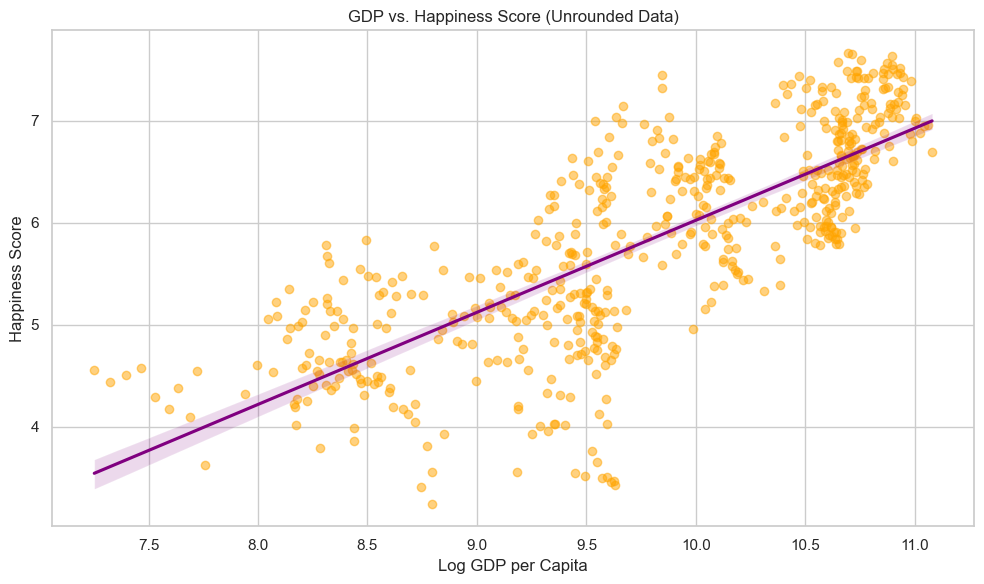

In [179]:

# Scatterplot with unrounded values
plt.figure(figsize=(10, 6))
sns.regplot(
    data=happiness_df_filtered_1,
    x='Log_GDP_per_Capita',
    y='Happiness_Score',
    scatter_kws={'alpha': 0.5, 'color': 'orange'},
    line_kws={'color': 'purple'}
)

plt.title("GDP vs. Happiness Score (Unrounded Data)")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Happiness Score")
plt.grid(True)
plt.tight_layout()
plt.show()


SUMMARY OF FINDINGS:
The original, unrounded data showed a clear relationship between GDP and happiness. Higher economic GDP generally aligned with higher happiness scores. Still, outliers exist in the original data.

In [180]:
# Dropped 'Generosity' column from the DataFrame
happiness_df_filtered_1 = happiness_df_filtered_1.drop(columns=['Generosity'])
print(happiness_df_filtered_1.head())


      country  Year  Happiness_Score  Log_GDP_per_Capita
43  Argentina  2006         6.312925            9.936886
44  Argentina  2007         6.073158           10.013071
45  Argentina  2008         5.961034           10.042918
46  Argentina  2009         6.424133            9.971766
47  Argentina  2010         6.441067           10.065660


In [181]:
missing_values = happiness_df_filtered_1.isnull().sum()
print(missing_values)

country               0
Year                  0
Happiness_Score       0
Log_GDP_per_Capita    1
dtype: int64


In [182]:
# Filling missing value in 'Log_GDP_per_Capita' with the median
median_val = happiness_df_filtered_1['Log_GDP_per_Capita'].median()
happiness_df_filtered_1['Log_GDP_per_Capita'] = happiness_df_filtered_1['Log_GDP_per_Capita'].fillna(median_val)

print(f"Filled missing 'Log_GDP_per_Capita' value with median: {median_val}")


Filled missing 'Log_GDP_per_Capita' value with median: 9.859636307


In [183]:
# Checking missing values
missing_counts = happiness_df_filtered_1.isna().sum()
print(missing_counts)

country               0
Year                  0
Happiness_Score       0
Log_GDP_per_Capita    0
dtype: int64


In [184]:
# DEV_FILTERED_1: Checking missing values in dev_df_filtered_1
missing_counts_1 = dev_df_filtered_1.isna().sum()
print(missing_counts_1)

country                                 0
Year                                    0
military_expenditure                   12
access_to_electricity                  36
population_density                     36
government_expenditure_on_education    95
government_health_expenditure          72
renewvable_energy_consumption          72
dtype: int64


In [185]:
print(dev_df_filtered_1.head())

       country  Year  military_expenditure  access_to_electricity  \
685  Argentina  2005              0.847155              96.725266   
686  Argentina  2006              0.788234              96.964409   
687  Argentina  2007              0.792548              97.224396   
688  Argentina  2008              0.762756              97.501602   
689  Argentina  2009              0.886509              97.792206   

     population_density  government_expenditure_on_education  \
685           14.276553                              3.86001   
686           14.425036                              4.12821   
687           14.570927                              4.46260   
688           14.716233                              4.84441   
689           14.866257                              5.53105   

     government_health_expenditure  renewvable_energy_consumption  
685                       3.913399                           9.64  
686                       4.018989                           9.1

In [186]:
print(dev_df_filtered_1.dtypes)

country                                 object
Year                                     Int32
military_expenditure                   float64
access_to_electricity                  float64
population_density                     float64
government_expenditure_on_education    float64
government_health_expenditure          float64
renewvable_energy_consumption          float64
dtype: object


In [187]:
# Checking missing values
missing_counts_d = dev_df_filtered_1.isna().sum()
print(missing_counts_d)

country                                 0
Year                                    0
military_expenditure                   12
access_to_electricity                  36
population_density                     36
government_expenditure_on_education    95
government_health_expenditure          72
renewvable_energy_consumption          72
dtype: int64


Filling missing values in dev_df_filtered_1

In [188]:
# Creating a copy
dev_df_filtered_1 = dev_df_filtered_1.copy()

# Looped through numeric columns with country specific median
for col in dev_df_filtered_1.select_dtypes(include=['float64', 'int64', 'Int32']).columns:
    if col not in ['Year']:  
        dev_df_filtered_1[col] = (
            dev_df_filtered_1.groupby('country')[col]
            .transform(lambda x: x.fillna(x.median()))
        )
        print(f"Filled missing values in '{col}' with country-specific median.")

Filled missing values in 'military_expenditure' with country-specific median.
Filled missing values in 'access_to_electricity' with country-specific median.
Filled missing values in 'population_density' with country-specific median.
Filled missing values in 'government_expenditure_on_education' with country-specific median.
Filled missing values in 'government_health_expenditure' with country-specific median.
Filled missing values in 'renewvable_energy_consumption' with country-specific median.


In [189]:
# Checking missing values
missing_counts_d = dev_df_filtered_1.isna().sum()
print(missing_counts_d)

country                                0
Year                                   0
military_expenditure                   0
access_to_electricity                  0
population_density                     0
government_expenditure_on_education    0
government_health_expenditure          0
renewvable_energy_consumption          0
dtype: int64


Created a column:
Created a dictionary to map countries to their development status, categorizing them as 'developed' or 'developing'. Applied this mapping to the happiness dataset to add a new column reflecting each country’s development status.

In [190]:
# Defined status by country name
dev_status_map = {
    'United States': 1,
    'Canada': 1,
    'Germany': 1,
    'France': 1,
    'United Kingdom': 1,
    'Italy': 1,
    'Spain': 1,
    'Netherlands': 1,
    'Poland': 1,
    'Japan': 1,
    'Korea, Rep.': 1,
    'Israel': 1,
    'Chile': 1,
    'Russian Federation': 1,

    # Developing = 0
    'South Africa': 0,
    'Kenya': 0,
    'Egypt, Arab Rep.': 0,
    'Ghana': 0,
    'Ethiopia': 0,
    'Botswana': 0,
    'China': 0,
    'India': 0,
    'Indonesia': 0,
    'Viet Nam': 0,
    'Bangladesh': 0,
    'Pakistan': 0,
    'Mexico': 0,
    'Cuba': 0,
    'Uruguay': 0,
    'Colombia': 0,
    'Argentina': 0,
    'Brazil': 0,
    'Peru': 0,
    'Iran, Islamic Rep.': 0,
    'Saudi Arabia': 0,
    'Ukraine': 0
}



In [191]:
# Applied mapping to create binary column
happiness_df_filtered_1['development_status'] = happiness_df_filtered_1['country'].map(dev_status_map)


In [192]:
print(happiness_df_filtered_1.head())

      country  Year  Happiness_Score  Log_GDP_per_Capita  development_status
43  Argentina  2006         6.312925            9.936886                   0
44  Argentina  2007         6.073158           10.013071                   0
45  Argentina  2008         5.961034           10.042918                   0
46  Argentina  2009         6.424133            9.971766                   0
47  Argentina  2010         6.441067           10.065660                   0


In [193]:
print(happiness_df_filtered_1['development_status'].dtype)


int64


In [194]:
# Converted the 'development_status' column to "int32" type 
happiness_df_filtered_1['development_status'] = happiness_df_filtered_1['development_status'].astype('int32')
print(happiness_df_filtered_1['development_status'].dtype)


int32


In [195]:

print(happiness_df_filtered_1)

        country  Year  Happiness_Score  Log_GDP_per_Capita  development_status
43    Argentina  2006         6.312925            9.936886                   0
44    Argentina  2007         6.073158           10.013071                   0
45    Argentina  2008         5.961034           10.042918                   0
46    Argentina  2009         6.424133            9.971766                   0
47    Argentina  2010         6.441067           10.065660                   0
...         ...   ...              ...                 ...                 ...
2150   Viet Nam  2018         5.295547            9.173263                   0
2151   Viet Nam  2019         5.467451            9.235229                   0
2152   Viet Nam  2020         5.462342            9.254416                   0
2153   Viet Nam  2021         5.540250            9.271268                   0
2154   Viet Nam  2022         6.266509            9.332854                   0

[578 rows x 5 columns]


In [196]:
# Checking missing values in 'development_status' column
missing_dev_status = happiness_df_filtered_1['development_status'].isna().sum()
print(f"Missing values in 'development_status': {missing_dev_status}")


Missing values in 'development_status': 0


In [197]:
# Finally merging the datasets
merged_df = pd.merge(
    happiness_df_filtered_1,
    dev_df_filtered_1,
    on=['country', 'Year'],
    how='left' 
)

# Checking the shape to confirm the merge
print("Merged DataFrame shape:", merged_df.shape)


Merged DataFrame shape: (578, 11)


DATASET MERGE:
I merged the World Happiness Report dataset (happiness_df_filtered_1) with the World Development Indicators dataset (dev_df_filtered_1), keeping only the countries and years that appear in both datasets. 

In [198]:
# Check the data
print(merged_df.columns.tolist)   

<bound method IndexOpsMixin.tolist of Index(['country', 'Year', 'Happiness_Score', 'Log_GDP_per_Capita',
       'development_status', 'military_expenditure', 'access_to_electricity',
       'population_density', 'government_expenditure_on_education',
       'government_health_expenditure', 'renewvable_energy_consumption'],
      dtype='object')>


In [75]:
# Print the head
print(merged_df.head())

     country  Year  Happiness_Score  Log_GDP_per_Capita  development_status  \
0  Argentina  2006         6.312925            9.936886                   0   
1  Argentina  2007         6.073158           10.013071                   0   
2  Argentina  2008         5.961034           10.042918                   0   
3  Argentina  2009         6.424133            9.971766                   0   
4  Argentina  2010         6.441067           10.065660                   0   

   military_expenditure  access_to_electricity  population_density  \
0              0.788234              96.964409           14.425036   
1              0.792548              97.224396           14.570927   
2              0.762756              97.501602           14.716233   
3              0.886509              97.792206           14.866257   
4              0.814878              98.820000           14.904302   

   government_expenditure_on_education  government_health_expenditure  \
0                              

In [199]:
print(merged_df['development_status'].head())

0    0
1    0
2    0
3    0
4    0
Name: development_status, dtype: int32


In [200]:
print(merged_df['Year'].dtype)


Int32


In [201]:
print(merged_df.dtypes)

country                                 object
Year                                     Int32
Happiness_Score                        float64
Log_GDP_per_Capita                     float64
development_status                       int32
military_expenditure                   float64
access_to_electricity                  float64
population_density                     float64
government_expenditure_on_education    float64
government_health_expenditure          float64
renewvable_energy_consumption          float64
dtype: object


Connecting and Merging Data in the SQLite Database.

In [202]:
import sqlite3

# Connecting to the SQLite database
conn = sqlite3.connect("world_happiness.db")


In [203]:
# Created a cursor object to interact with the database
cursor = conn.cursor()

# Dropped tables 
cursor.execute("DROP TABLE IF EXISTS happiness")
cursor.execute("DROP TABLE IF EXISTS development")

# Created tables with primary keys
cursor.execute("""
CREATE TABLE happiness (
    country TEXT,
    Year INTEGER,
    Happiness_Score REAL,
    Log_GDP_per_Capita REAL,
    development_status INTEGER,
    PRIMARY KEY (country, Year)
)
""")

cursor.execute("""
CREATE TABLE development (
    country TEXT,
    Year INTEGER,
    military_expenditure REAL,
    access_to_electricity REAL,
    population_density REAL,
    government_expenditure_on_education REAL,
    government_health_expenditure REAL,
    renewable_energy_consumption REAL,
    PRIMARY KEY (country, Year)
)
""")
#  # Save all changes
conn.commit() 

In [204]:
happiness_df_filtered_1.to_sql("happiness", conn, if_exists="replace", index=False)
dev_df_filtered_1.to_sql("development", conn, if_exists="replace", index=False)


648

In [205]:
# Joined happiness and development data by country and year to the datasets indicators
query = """
SELECT 
    happiness.country,
    happiness.Year,
    happiness.Happiness_Score,
    happiness.Log_GDP_per_Capita,
    happiness.development_status,
    development.military_expenditure,
    development.access_to_electricity,
    development.population_density,
    development.government_expenditure_on_education,
    development.government_health_expenditure,
    development.renewvable_energy_consumption
FROM happiness
LEFT JOIN development 
ON happiness.country = development.country 
AND happiness.Year = development.Year
"""


In [206]:
# Saved results in merged_sql_df
merged_sql_df = pd.read_sql_query(query, conn)

# Checked the head
print(merged_sql_df.head())

     country  Year  Happiness_Score  Log_GDP_per_Capita  development_status  \
0  Argentina  2006         6.312925            9.936886                   0   
1  Argentina  2007         6.073158           10.013071                   0   
2  Argentina  2008         5.961034           10.042918                   0   
3  Argentina  2009         6.424133            9.971766                   0   
4  Argentina  2010         6.441067           10.065660                   0   

   military_expenditure  access_to_electricity  population_density  \
0              0.788234              96.964409           14.425036   
1              0.792548              97.224396           14.570927   
2              0.762756              97.501602           14.716233   
3              0.886509              97.792206           14.866257   
4              0.814878              98.820000           14.904302   

   government_expenditure_on_education  government_health_expenditure  \
0                              

In [207]:
print(merged_sql_df.columns)

Index(['country', 'Year', 'Happiness_Score', 'Log_GDP_per_Capita',
       'development_status', 'military_expenditure', 'access_to_electricity',
       'population_density', 'government_expenditure_on_education',
       'government_health_expenditure', 'renewvable_energy_consumption'],
      dtype='object')



This chart shows how happy each country is on average. Every bar represents one country's happiness score.Taller bars mean a higher happiness score.Countries are sorted from most happy to least happy. Colors move from orange (lower scores) to purple (higher scores) using a gradient.The chart helps us quickly see which countries are doing well and which are lower on the happiness scale. Countries like the Netherlands and Israel are at the top, while Ethiopia and Botswana are toward the bottom.

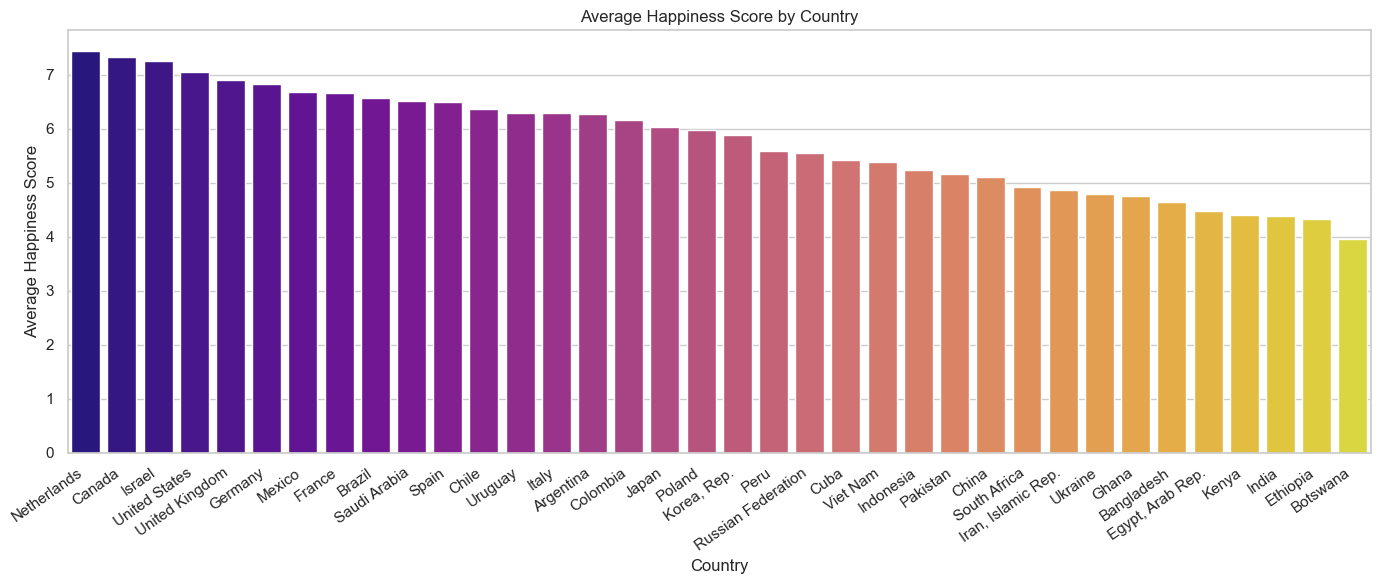

In [208]:

# Grouped by country and calculated average Happiness Score
happiness_avg = merged_sql_df.groupby('country')['Happiness_Score'].mean().reset_index()

# Sorted countries by descending happiness
happiness_avg = happiness_avg.sort_values(by='Happiness_Score', ascending=False)

# Plot
plt.figure(figsize=(14, 6))
sns.barplot(data=happiness_avg, x='country', y='Happiness_Score', hue='country', palette='plasma')

plt.title('Average Happiness Score by Country')
plt.xlabel('Country')
plt.ylabel('Average Happiness Score')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [209]:
merged_sql_df_copy = merged_sql_df.copy()


In [210]:
print(merged_sql_df.columns)

Index(['country', 'Year', 'Happiness_Score', 'Log_GDP_per_Capita',
       'development_status', 'military_expenditure', 'access_to_electricity',
       'population_density', 'government_expenditure_on_education',
       'government_health_expenditure', 'renewvable_energy_consumption'],
      dtype='object')


Compared average military expenditure  with average happiness scores across the countries.

In [211]:
military_averages = merged_sql_df.groupby('country')[['military_expenditure', 'Happiness_Score']].mean()
print(military_averages)


                    military_expenditure  Happiness_Score
country                                                  
Argentina                       0.766936         6.283633
Bangladesh                      1.136319         4.638195
Botswana                        2.765615         3.953261
Brazil                          1.381424         6.563506
Canada                          1.211179         7.323657
Chile                           2.093748         6.364782
China                           1.734924         5.098935
Colombia                        3.286776         6.171113
Cuba                            3.205681         5.417869
Egypt, Arab Rep.                1.682013         4.470624
Ethiopia                        0.715886         4.322007
France                          1.921962         6.665637
Germany                         1.221923         6.824170
Ghana                           0.365429         4.756209
India                           2.614036         4.387353
Indonesia     

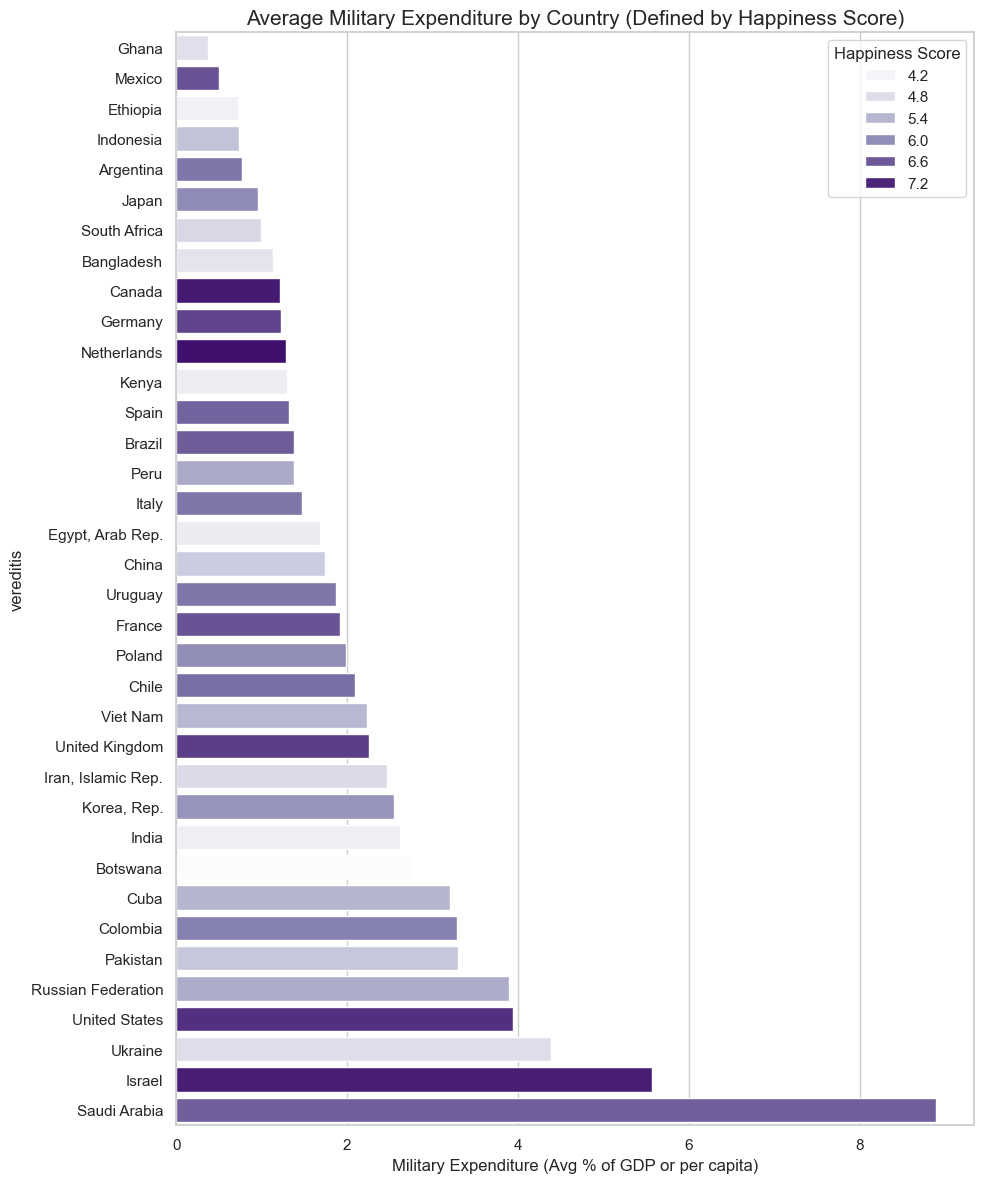

In [240]:
# Sorting the data
sorted_avg_df = military_averages.sort_values('military_expenditure', ascending=True)

plt.figure(figsize=(10, 12))

sns.barplot(
    data=sorted_avg_df,
    x='military_expenditure',
    y='country',
    hue='Happiness_Score',
    palette='Purples',  
    dodge=False
)

# Plotting
plt.title('Average Military Expenditure by Country (Defined by Happiness Score)', fontsize=15)
plt.xlabel('Military Expenditure (Avg % of GDP or per capita)')
plt.ylabel('vereditis')
plt.legend(title='Happiness Score')
plt.tight_layout()
plt.show()

FINDINGS

Countries with high military expenditure don't consistently report higher happiness scores. For example:

Based on the data i just analysed -  greater military spending doesn’t necessarily correlate with greater national happiness, still some outliers exist. 

Compared average population density per square kilometer with average happiness scores across the countries from 2005 to 2022.


In [213]:
# Calculated the mean values from 2005-2022.
pop_den_averages = merged_sql_df.groupby('country')[['population_density', 'Happiness_Score']].mean()
print(pop_den_averages)


                    population_density  Happiness_Score
country                                                
Argentina                    15.530903         6.283633
Bangladesh                 1192.555065         4.638195
Botswana                      3.941997         3.953261
Brazil                       24.183618         6.563506
Canada                        3.941196         7.323657
Chile                        23.845526         6.364782
China                       145.492848         5.098935
Colombia                     42.111120         6.171113
Cuba                        105.803157         5.417869
Egypt, Arab Rep.             94.906225         4.470624
Ethiopia                     92.752631         4.322007
France                      120.356428         6.665637
Germany                     235.012690         6.824170
Ghana                       122.545124         4.756209
India                       435.785412         4.387353
Indonesia                   135.197837         5

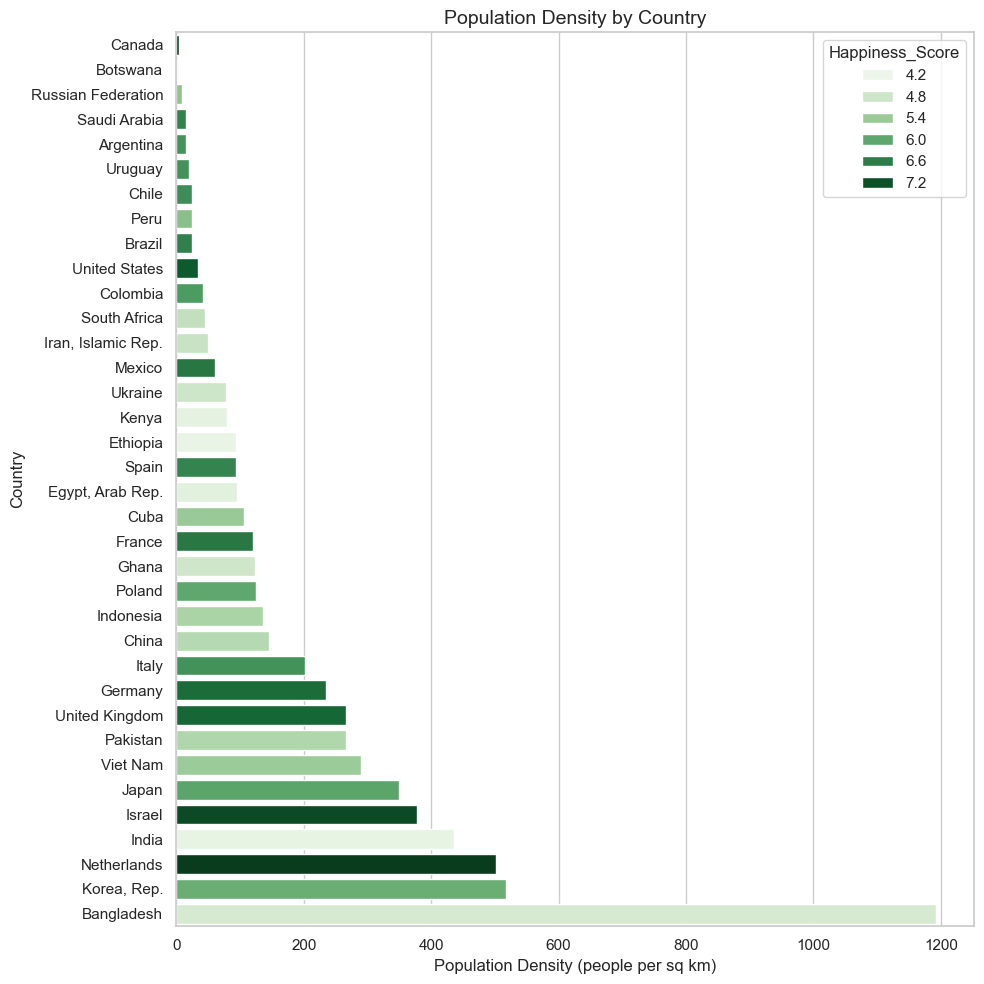

In [242]:

# Sort for tidy layout
sorted_den_df = pop_den_averages.sort_values('population_density', ascending=True)

plt.figure(figsize=(10, 10))

sns.barplot(
    data=sorted_den_df,
    x='population_density',
    y='country',
    hue='Happiness_Score',
    palette='Greens',
    dodge=False
)


# Customized the plot
plt.title('Population Density by Country', fontsize=14)
plt.ylabel('Country')
plt.xlabel('Population Density (people per sq km)')
plt.legend(title='Happiness_Score')
plt.tight_layout()
plt.show()

Conclusions:
Based on our visual i can conclude as population density increases, happiness tends to decrease a little bit. 

Nevertheless, i  noticed that there is a partial linear relationship between population density and happiness scores. Countries with high density, such as the Netherlands and the United Kingdom, still report above-average happiness, challenging the assumption that crowding diminishes well-being. While Bangladesh and India show the opposite.


Compared average government spending on education with average happiness scores across countries.

In [215]:
# Created a dataframe and calculated the mean values from 2005-2022.
education_averages = merged_sql_df.groupby('country')[['government_expenditure_on_education', 'Happiness_Score']].mean()
print(education_averages)


                    government_expenditure_on_education  Happiness_Score
country                                                                 
Argentina                                      5.121096         6.283633
Bangladesh                                     1.964212         4.638195
Botswana                                       8.363567         3.953261
Brazil                                         5.736693         6.563506
Canada                                         4.796577         7.323657
Chile                                          4.583761         6.364782
China                                          3.589006         5.098935
Colombia                                       4.502902         6.171113
Cuba                                           9.057170         5.417869
Egypt, Arab Rep.                               3.809699         4.470624
Ethiopia                                       4.790932         4.322007
France                                         5.48

Analysis of the relationship between education expenditure and happiness across countries from 2005 to 2022.

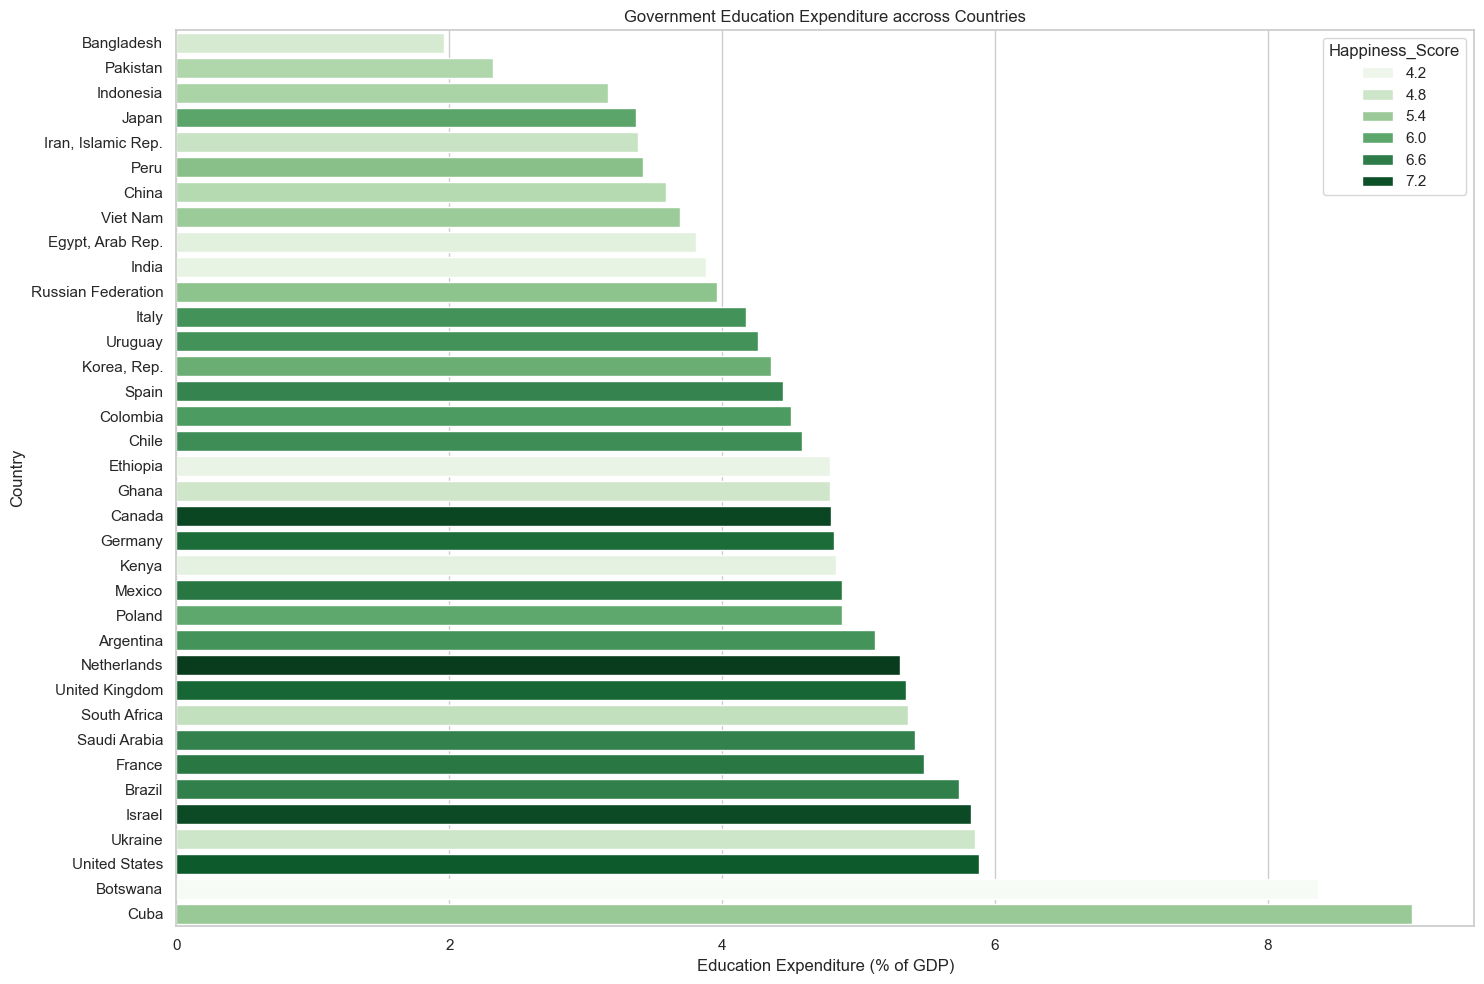

In [243]:
# Sorted countries 
sorted_df_education = education_averages.sort_values('government_expenditure_on_education', ascending=True)

# Plotted horizontal barplot
plt.figure(figsize=(15, 10))

sns.barplot(
    data=sorted_df_education, 
    y='country',
    hue='Happiness_Score',
    palette='Greens',
    x='government_expenditure_on_education',
)

plt.title('Government Education Expenditure accross Countries')
plt.ylabel('Country')
plt.xlabel('Education Expenditure (% of GDP)')
plt.tight_layout()
plt.show()

FINDINGS
There's a general positive correlation between education spending and happiness — more investment, means higher happiness scores.
But it’s not perfectly linear. Some well-funded countries don’t top the happiness scale, and vice versa. For eample, like Cuba or Botswana spends a lot on education but the happiness scores are low. 


Analysis of the relationship between government health expenditure and happiness across countries from 2005 to 2022.

In [247]:
# Created Dataframe and calculated the mean values from 2005-2022.
health_average = merged_sql_df.groupby('country')[['government_health_expenditure', 'Happiness_Score']].mean()
print(health_average)



                    government_health_expenditure  Happiness_Score
country                                                           
Argentina                                5.745968         6.283633
Bangladesh                               0.543045         4.638195
Botswana                                 3.948454         3.953261
Brazil                                   3.714222         6.563506
Canada                                   7.539333         7.323657
Chile                                    3.814949         6.364782
China                                    2.474129         5.098935
Colombia                                 5.173322         6.171113
Cuba                                     7.080490         5.417869
Egypt, Arab Rep.                         1.506631         4.470624
Ethiopia                                 0.901339         4.322007
France                                   8.101181         6.665637
Germany                                  8.475651         6.82

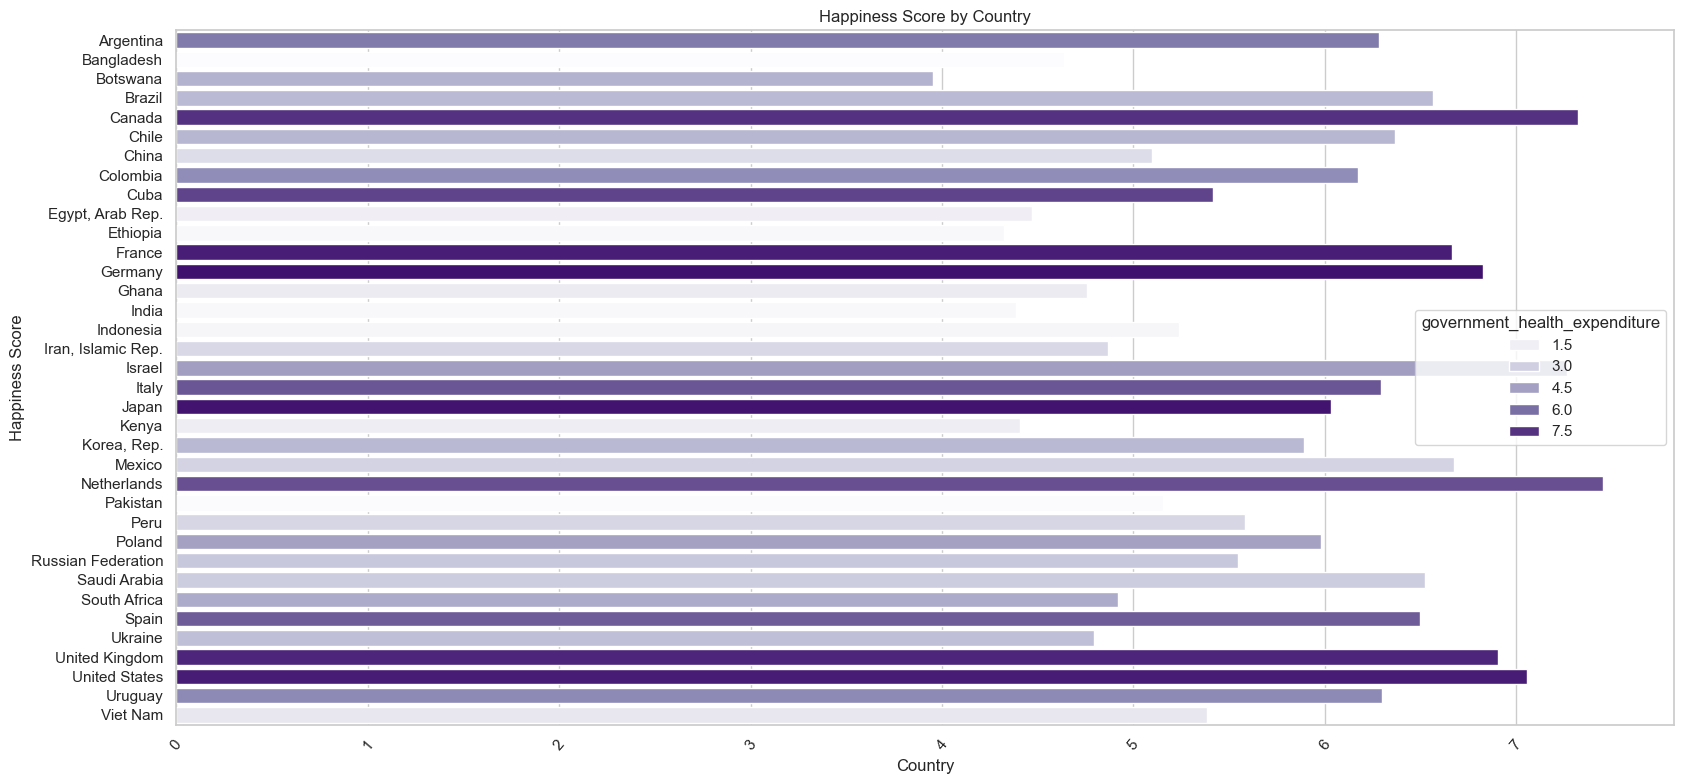

In [248]:
plt.figure(figsize=(17, 8))
sns.barplot(data=health_average,
            y='country',
            x='Happiness_Score',
            hue='government_health_expenditure',
            palette='Purples')

plt.title('Happiness Score by Country')
plt.xlabel('Country')
plt.ylabel('Happiness Score')
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

Findings
I can observe a strong positive relationship between national health expenditure and average happiness scores. In general, countries  that invest a greater share of GDP in healthcare rank higher in happiness.


In [221]:
print(merged_sql_df.columns)

Index(['country', 'Year', 'Happiness_Score', 'Log_GDP_per_Capita',
       'development_status', 'military_expenditure', 'access_to_electricity',
       'population_density', 'government_expenditure_on_education',
       'government_health_expenditure', 'renewvable_energy_consumption'],
      dtype='object')


In [222]:
print(pop_den_averages.columns)

Index(['population_density', 'Happiness_Score'], dtype='object')


In [223]:
print(happiness_avg.head())

           country  Happiness_Score
23     Netherlands         7.451992
4           Canada         7.323657
17          Israel         7.265653
33   United States         7.059055
32  United Kingdom         6.903213



Grouped data by country and calculated the mean values from 2005 to 2022, for average renewable energy usage and average happiness score.

In [224]:
# Created dataframe 
renew_energy_avg = merged_sql_df.groupby('country')[['renewvable_energy_consumption', 'Happiness_Score']].mean()
print(renew_energy_avg)

                    renewvable_energy_consumption  Happiness_Score
country                                                           
Argentina                                9.228235         6.283633
Bangladesh                              36.258235         4.638195
Botswana                                27.110000         3.953261
Brazil                                  45.921176         6.563506
Canada                                  21.803529         7.323657
Chile                                   28.002941         6.364782
China                                   13.202813         5.098935
Colombia                                30.648235         6.171113
Cuba                                    21.960000         5.417869
Egypt, Arab Rep.                         5.568824         4.470624
Ethiopia                                91.043000         4.322007
France                                  12.681176         6.665637
Germany                                 13.361765         6.82

Created bar plot showing the average renewable energy consumption and happiness scores from 2005 to 2022.

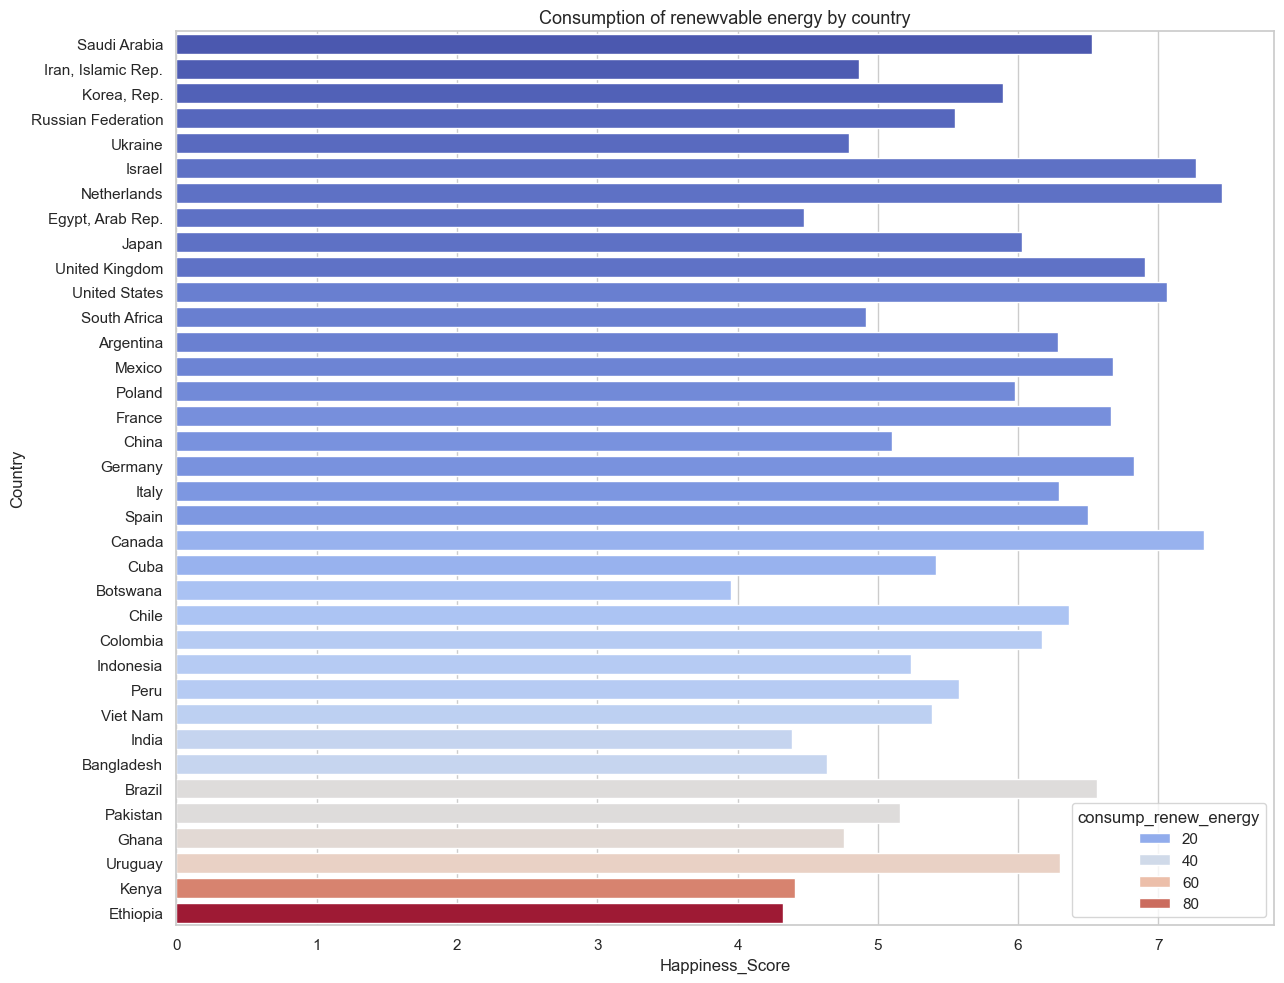

In [225]:
# Sort to make it neat
sorted_renew_energy_df = renew_energy_avg.sort_values('renewvable_energy_consumption', ascending=True)

plt.figure(figsize=(13, 10))

sns.barplot(
    data=sorted_renew_energy_df,
    y='country',
    hue='renewvable_energy_consumption',
    x='Happiness_Score',
    palette='coolwarm',
    dodge=False
)


# Customized the plot
plt.title('Consumption of renewvable energy by country', fontsize=13)
plt.xlabel('Happiness_Score')
plt.ylabel('Country')
plt.legend(title='consump_renew_energy')
plt.tight_layout()
plt.show()

 CONCLUSION
There is a moderate negative correlation between renewable energy consumption and happiness scores.

Analysis of the relationship between access to electricity and happiness across countries

In [226]:
# Calculated the average electricity access and happiness score for each country
electricity_averages = merged_sql_df.groupby('country')[['access_to_electricity', 'Happiness_Score']].mean()
print(electricity_averages)

                    access_to_electricity  Happiness_Score
country                                                   
Argentina                       99.096162         6.283633
Bangladesh                      69.841523         4.638195
Botswana                        57.958843         3.953261
Brazil                          99.215957         6.563506
Canada                         100.000000         7.323657
Chile                           99.592664         6.364782
China                           99.632193         5.098935
Colombia                        97.716894         6.171113
Cuba                            96.935410         5.417869
Egypt, Arab Rep.                99.636358         4.470624
Ethiopia                        37.622845         4.322007
France                         100.000000         6.665637
Germany                        100.000000         6.824170
Ghana                           70.939760         4.756209
India                           84.324213         4.3873

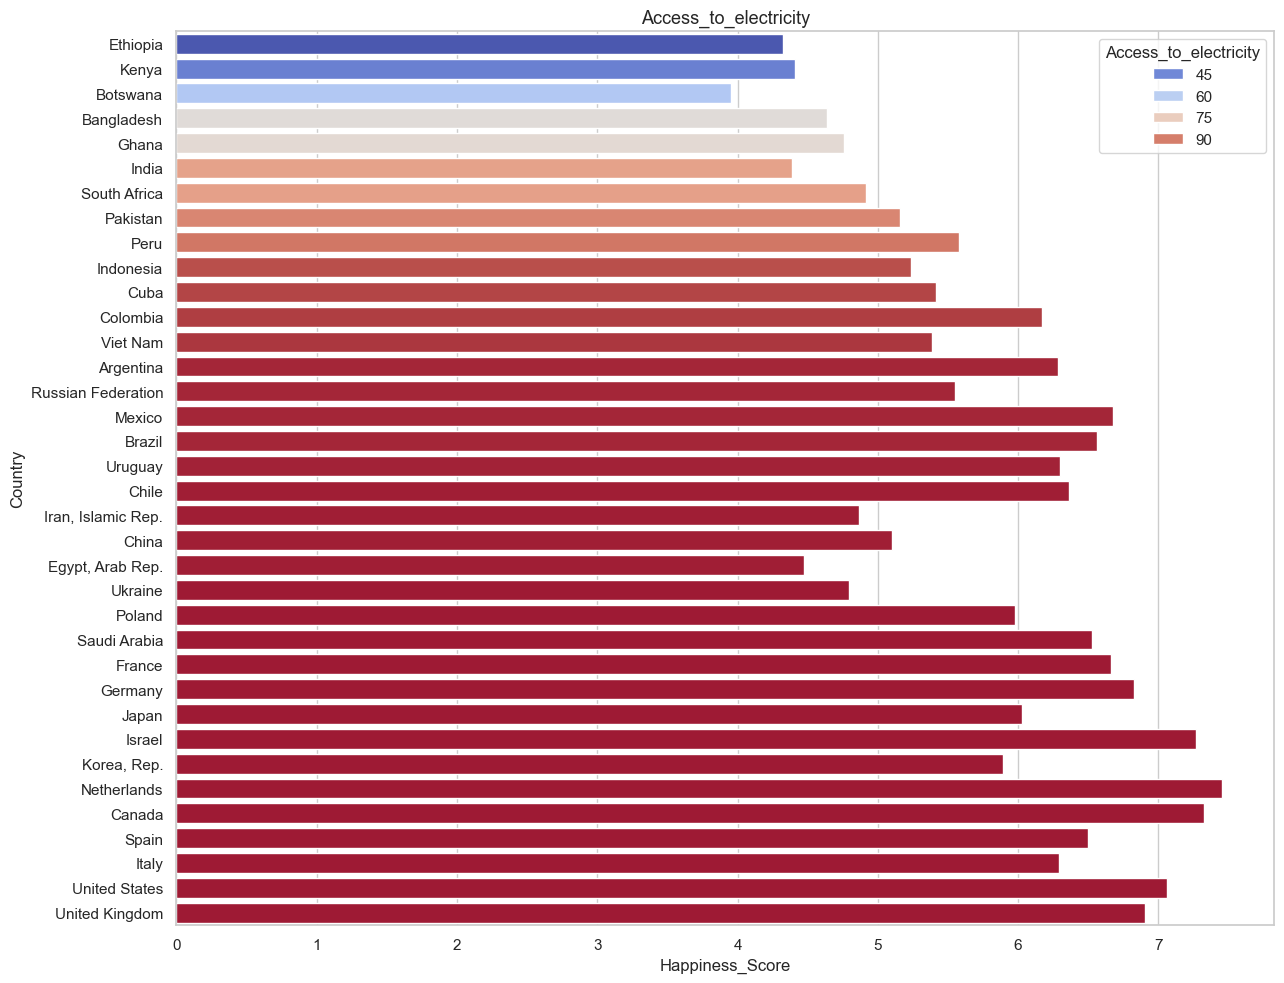

In [227]:
# Sort to make it neat
sorted_elec_aveg_df = electricity_averages.sort_values('access_to_electricity', ascending=True)

plt.figure(figsize=(13, 10))

sns.barplot(
    data=sorted_elec_aveg_df,
    hue='access_to_electricity',
    x='Happiness_Score',
    y='country',
     palette='coolwarm',
)


# Customized the plot
plt.title('Access_to_electricity', fontsize=13)
plt.xlabel('Happiness_Score')
plt.ylabel('Country')
plt.legend(title='Access_to_electricity')
plt.tight_layout()
plt.show()

Conclusion:
There is moderate correlation between access to electricity and happiness.
According to the plot Greater electricity access often aligns with higher happiness.


Analysis of the relationship between Log_GDP_per_Capita and happiness across countries from 2005 to 2022.

In [228]:
# Calculated the average GDP and happiness score for each country
GDP_averages = merged_sql_df.groupby('country')[['Log_GDP_per_Capita','Happiness_Score']].mean()
print(GDP_averages)

                    Log_GDP_per_Capita  Happiness_Score
country                                                
Argentina                    10.030438         6.283633
Bangladesh                    8.335794         4.638195
Botswana                      9.550158         3.953261
Brazil                        9.585347         6.563506
Canada                       10.753692         7.323657
Chile                        10.045226         6.364782
China                         9.307890         5.098935
Colombia                      9.486774         6.171113
Cuba                          9.859636         5.417869
Egypt, Arab Rep.              9.218245         4.470624
Ethiopia                      7.536613         4.322007
France                       10.678276         6.665637
Germany                      10.822259         6.824170
Ghana                         8.386565         4.756209
India                         8.523432         4.387353
Indonesia                     9.164961         5

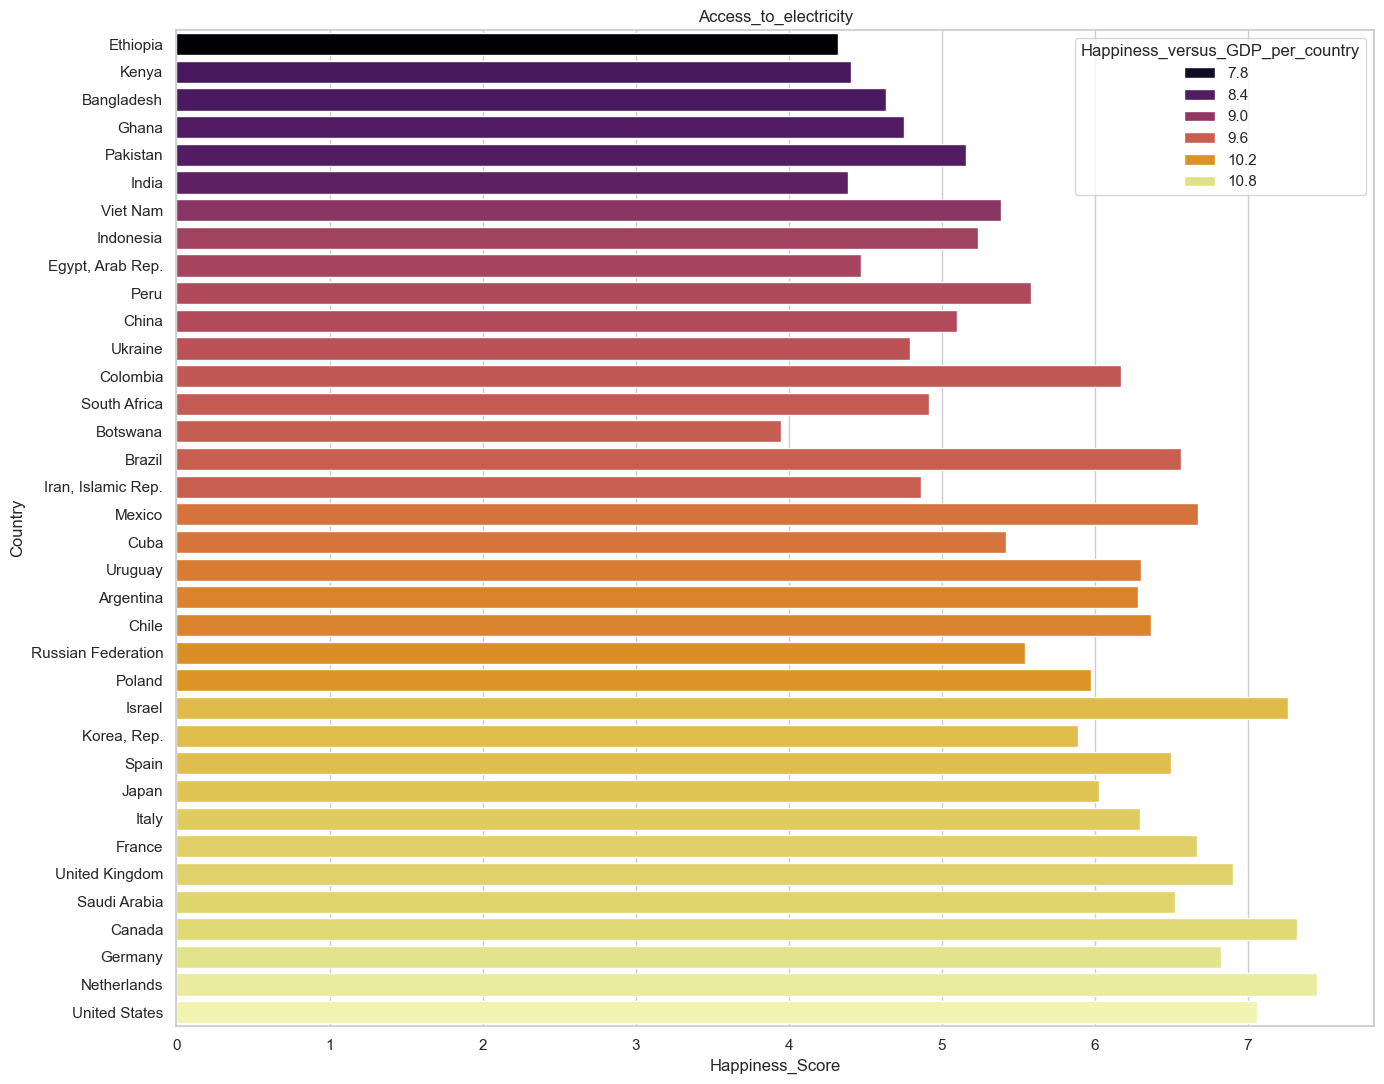

In [230]:
# Sort to make it neat

sorted_GDP_aveg_df = GDP_averages.sort_values(
    by=['Log_GDP_per_Capita', 'Happiness_Score'],
    ascending=True
)


plt.figure(figsize=(14, 11))

sns.barplot(
    data=sorted_GDP_aveg_df,
    hue='Log_GDP_per_Capita',
    x='Happiness_Score',
    y='country',
     palette='inferno',
)


# Customized the plot
plt.title('Access_to_electricity', fontsize=12)
plt.xlabel('Happiness_Score')
plt.ylabel('Country')
plt.legend(title='Happiness_versus_GDP_per_country')
plt.tight_layout()
plt.show()

Findings:
There is a positive relationship betwen Log GDP per capita and Happiness. 

The line plot visualizes trends across multiple countries with each indicator plotted as a separate line across the same x-axis of country names and  compares the following five indicators:
Log_GDP__per_Capita
Access to Electricity
Government expenditure on education
Happiness Score
Military expenditure

In [231]:
# Resetting index for all summary Dataframes to restore 'country' as a column
GDP_averages = GDP_averages.reset_index()
happiness_avg = happiness_avg.reset_index()
electricity_averages = electricity_averages.reset_index()
education_averages = education_averages.reset_index()
military_averages = military_averages.reset_index()


In [232]:
# Forgot to reset with the rest
health_average = health_average.reset_index

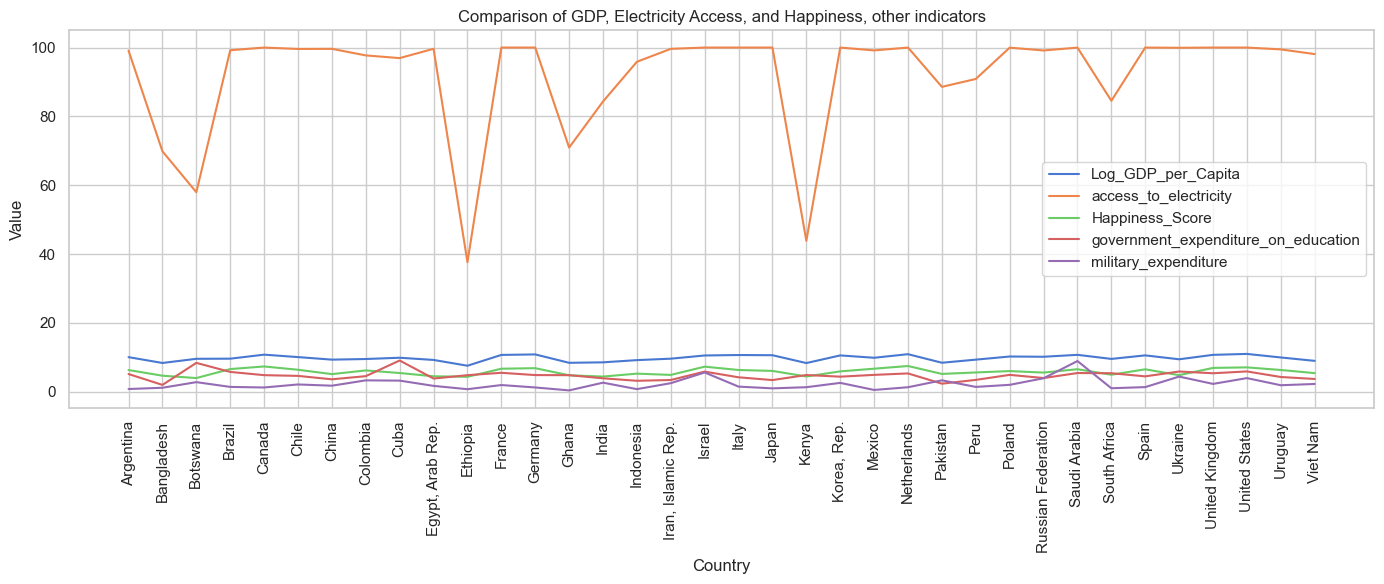

In [233]:
import matplotlib.pyplot as plt
import pandas as pd

# First, merged selected columns from each DataFrame
merged_df_final = GDP_averages[['country', 'Log_GDP_per_Capita']] \
    .merge(happiness_avg[['country', 'Happiness_Score']], on='country')\
    .merge(electricity_averages[['country', 'access_to_electricity']], on='country') \
    .merge(education_averages[['country', 'government_expenditure_on_education']], on='country')\
    .merge(military_averages[['country', 'military_expenditure']], on='country')
    

# Sorted the data
merged_df_final_1 = merged_df_final.sort_values('country')

# Using melt function
plot_df = merged_df_final_1.melt(id_vars='country', 
    value_vars=['Log_GDP_per_Capita', 'access_to_electricity', 'Happiness_Score', 'government_expenditure_on_education', 'military_expenditure'],
    var_name='Indicator', 
     value_name='Value')

# Created the plot
plt.figure(figsize=(14,6))
for indicator in plot_df['Indicator'].unique():
    data = plot_df[plot_df['Indicator'] == indicator]
    plt.plot(data['country'], data['Value'], label=indicator)

plt.xticks(rotation=90)
plt.ylabel('Value')
plt.xlabel('Country')
plt.title('Comparison of GDP, Electricity Access, and Happiness, other indicators')
plt.legend()
plt.tight_layout()
plt.show()

In [234]:
print(type(health_average))


<class 'method'>


Findings:
GDP vs. Happiness: A positive correlation is observable; wealthier nations tend to report higher happiness scores.
Electricity Access vs. Happiness: Also positively correlated, reflecting the foundational role of infrastructure in well-being.
Education Spending vs. Happiness: Slight positive correlation, though the signal is weaker and less consistent across countries.
Military Spending vs. Happiness: There is a weak correlation between military spending and happiness.


Examined how each development indicator relates to the Happiness Score by performing correlation analysis. This helped us to see  thestrenth and direction of the relationship. 
Used p-value analysis to test whether these relationships are statistically significant, meaning they are unlikely to be due to random chance.
Together, these methods helped identify which factors are more meaningfully linked to national happiness.


In [235]:
from scipy.stats import pearsonr
import pandas as pd

# Defined my indicators
indicators = [
    'Log_GDP_per_Capita',
    'military_expenditure',
    'access_to_electricity',
    'population_density',
    'government_expenditure_on_education',
    'government_health_expenditure',
    'renewvable_energy_consumption'
]

# Dropped missing values
df_corr = merged_sql_df[['Happiness_Score'] + indicators].dropna()

# Stored results
correlation_results = []

for col in indicators:
    r, p = pearsonr(df_corr['Happiness_Score'], df_corr[col])
    correlation_results.append({
        'Indicator': col,
        'Correlation Coefficient': round(r, 4),
        'P-value': round(p, 4)
    })

# Converted to DataFrame for a better display
results_df = pd.DataFrame(correlation_results).sort_values(by='Correlation Coefficient', ascending=False)
print(results_df)

                             Indicator  Correlation Coefficient  P-value
0                   Log_GDP_per_Capita                   0.7747   0.0000
5        government_health_expenditure                   0.6846   0.0000
2                access_to_electricity                   0.5564   0.0000
4  government_expenditure_on_education                   0.2433   0.0000
1                 military_expenditure                   0.1035   0.0128
3                   population_density                  -0.0957   0.0213
6        renewvable_energy_consumption                  -0.3756   0.0000



KEY FINDINGS BASED ON THE DATA EXPLORED

Happiness and GDP per Capita (Log):
There is a strong positive relationship — countries with higher economic output per person tend to report higher happiness scores.

Happiness and Government Health Expenditure:
A clear positive correlation shows that countries investing more in public healthcare tend to have happier populations.

GDP and Health Expenditure:
These two indicators rise together, suggesting that wealthier nations are more able (and likely) to spend on healthcare services.

Happiness and Military Expenditure:
There is a very weak correlation, although statistically significant—likely not a core driver of happiness.
There is no consistent pattern — spending on defense does not appear to significantly impact happiness.

Based on our correlation coefficient analysis, access to electricity has a moderate positive correlation with the level of happiness. According to the p-value analysis, this relationship is statistically significant.

There is a moderate negative correlation between renewable energy consumption and happiness scores.

There is  a weak negative correlation between happiness and population density, it may slightly decrease well-being.